In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

sys.path.insert(0,'/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE')
import aymansigmri as asm

In [2]:
def inner_portion(enlarged_kspace, inner_sidelen):
    """Take an inner square of kspace to speed up the hankel loop

        Args:
            enlarged_kspace: Zero padded kspace in cartesian coordinates (n_coils, nx, ny)
            inner_sidelen: Side legnth of the inner square, divided by 2 to find from central point outward

        Returns:
            isolated_kspace: Inner kspace array
            isolation_mask: Mask of the inner region to use when 'jigsawing' the transformed array back in
            Start: xy index of the enlarged array that the inner region starts at
            End: xy index of the enlarged array that the inner region ends at
    """
    cx, cy = enlarged_kspace.shape[1] // 2, enlarged_kspace.shape[2] // 2
    N = inner_sidelen/2
    start, end = int(cx-N), int(cx+N)
    isolation_mask = np.ones(enlarged_kspace.shape[1:], dtype=int)
    isolation_mask[start:end, start:end] = 0
    isolated_kspace = enlarged_kspace[:, start:end, start:end]
    
    return(isolated_kspace, isolation_mask, start, end)



def jigsaw(output_kspace, isolation_mask, start, end, enlarged_kspace):
    ### NOTE: There is a better way to do this without using start and end
    """Put the transormed region of kspace back into the zero padded region
        Args:
            output_kspace: Transformed SVD thresh kspace region
            isolation_mask: Mask of the inner region; typically output of asm.inner_portion
            Start: xy index of the enlarged array that the inner region starts at; typically output of asm.inner_portion 
            End: xy index of the enlarged array that the inner region ends at; typically output of asm.inner_portion
            enlarged_kspace: Zero padded kspace in cartesian coordinates (n_coils, nx, ny)

        Returns:
            recombined: Zero padded kspace with transfomed inner region 'jigsawed' back in
    """
    processed_isolated_kspace = output_kspace.copy()
    recombined = enlarged_kspace * isolation_mask ### NOTE: Need to improve this
    recombined[:, start:end, start:end] = processed_isolated_kspace
    return(recombined)

def plot_mask(isolated_kspace, mask, zte_radial_coords, zte_radial_kspace, innersidelen, sidelencart, sidelenrad):
    
    all_coords = zte_radial_coords.reshape(-1, 2)

    fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 8))
    
    im = ax[0].imshow(np.abs(isolated_kspace[0]), cmap='viridis', origin='lower')
    fig.colorbar(im, ax=ax[0], label='kspace value')
    ax[0].set_title('Cartesian')
    ax[0].set_xlabel('kx')
    ax[0].set_ylabel('ky')
    ax[0].set_xlim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
    ax[0].set_ylim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
    ax[0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[0].grid(visible=True, which='minor', linewidth=1)
    ax[0].xaxis.set_major_locator(plt.MultipleLocator(1))
    ax[0].yaxis.set_major_locator(plt.MultipleLocator(1))


    yy, xx = np.mgrid[0:mask.shape[0], 0:mask.shape[0]]
    im1 = ax[1].scatter(xx.ravel(), yy.ravel(), c=mask.ravel().astype(int), cmap='viridis', s=300, marker='s', zorder=3)
    fig.colorbar(im1, ax=ax[1], label='mask')
    ax[1].set_title('Centre mask')
    ax[1].set_xlabel('x')
    ax[1].set_ylabel('y')
    ax[1].axis('equal')
    ax[1].set_xlim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
    ax[1].set_ylim(innersidelen/2 - sidelencart,innersidelen/2 + sidelencart)
    ax[1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[1].grid(visible=True, which='minor', linewidth=1)
    ax[1].xaxis.set_major_locator(plt.MultipleLocator(1))
    ax[1].yaxis.set_major_locator(plt.MultipleLocator(1))

    im2 = ax[2].scatter(all_coords[:, 0],all_coords[:, 1], c=np.abs(zte_radial_kspace[1]), cmap='viridis')
    fig.colorbar(im2, ax=ax[2], label='kspace value')
    ax[2].set_title('Radial')
    ax[2].set_xlabel('kx')
    ax[2].set_ylabel('ky')
    ax[2].axis('equal')
    ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
    ax[2].grid(visible=True, which='minor', linewidth=1)
    ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
    ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
    ax[2].set_xlim(0 - (sidelenrad//2), 0 + (sidelenrad//2))
    ax[2].set_ylim(0 - sidelenrad//2, 0 + (sidelenrad//2))

    plt.show()

In [8]:
width=4
gap = 2
num_iters = 50

resize_wid=1024
rw_div2 = int(resize_wid/2)

inner_wid=100
indiv2 = int(inner_wid/2)

In [9]:
zte_radial_kspacedlt, zte_radial_coordsdlt, zte_radial_kspacezero, zte_radial_coordszero, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=(gap), undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacezero, coords=zte_radial_coordszero)

cartesian_kspace_enl = asm.zero_padding(cart_kspace=cartesian_zte, resize_x=resize_wid, resize_y=resize_wid)

inner_region, inner_mask, start, end = inner_portion(enlarged_kspace=cartesian_kspace_enl, inner_sidelen=inner_wid)

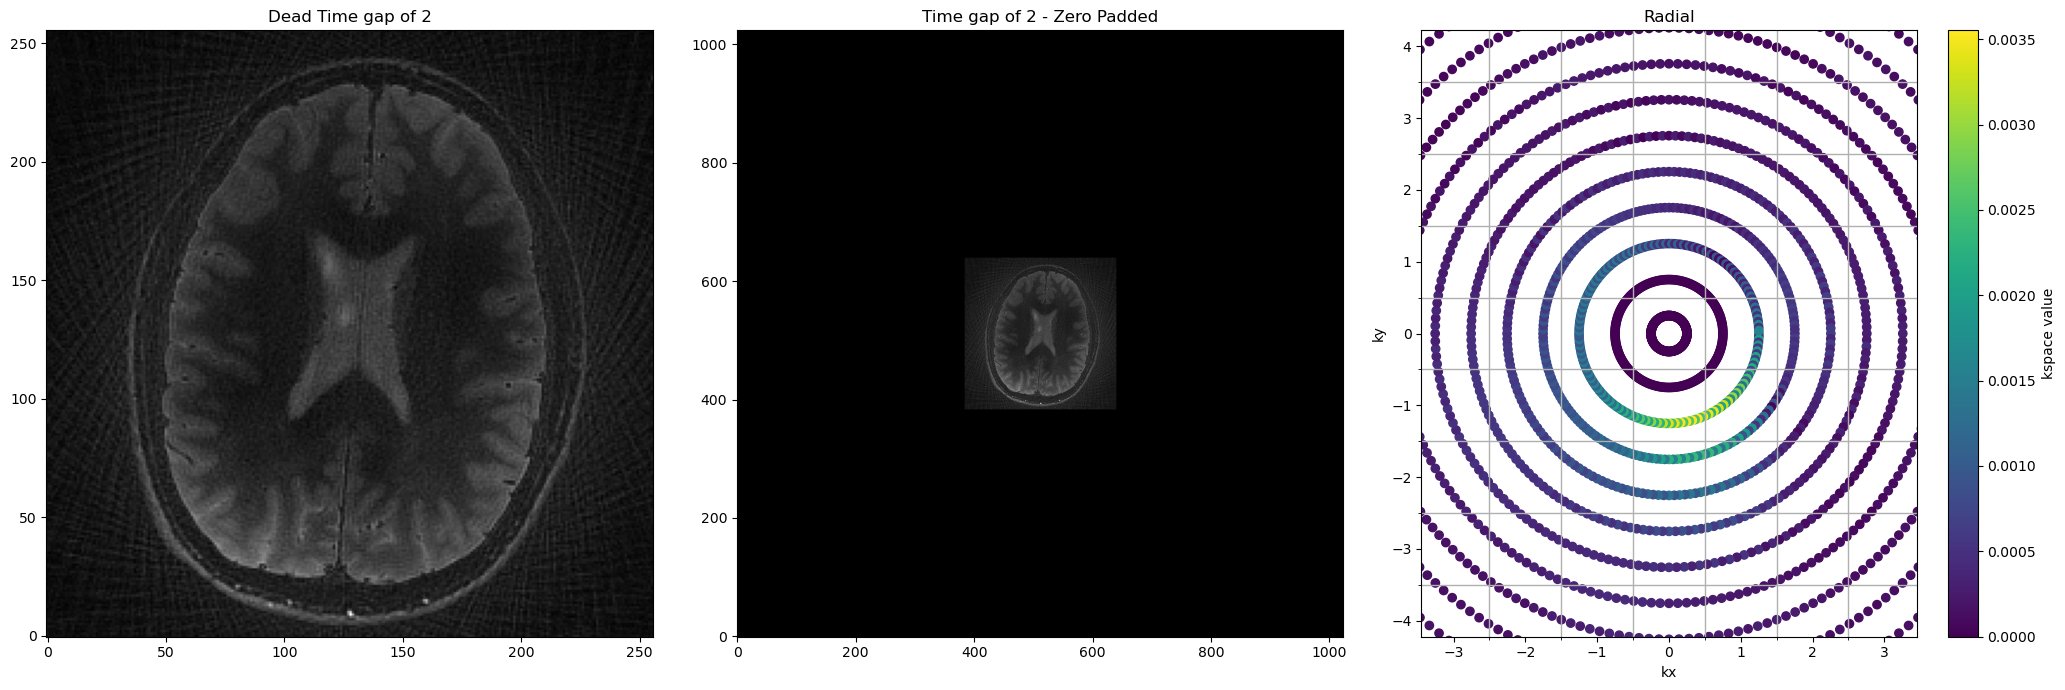

In [10]:
fig, ax = plt.subplots(1, 3, figsize=(21, 7))

im_grid1 = sp.ifft(cartesian_zte, axes=(-2, -1))
im_1 = np.sum(np.abs(im_grid1)**2, axis=0)**0.5
ax[0].imshow(im_1, cmap='gray', origin='lower')
ax[0].set_title(f'Dead Time gap of {gap}')

im_grid2 = sp.ifft(cartesian_kspace_enl, axes=(-2, -1))
im_2 = np.sum(np.abs(im_grid2)**2, axis=0)**0.5
ax[1].imshow(im_2, cmap='gray', origin='lower')
ax[1].set_title(f'Time gap of {gap} - Zero Padded')


zte_radial_coordszero = zte_radial_coordszero.reshape(-1, 2)

im2 = ax[2].scatter(zte_radial_coordszero[:, 0],zte_radial_coordszero[:, 1], c=np.abs(zte_radial_kspacezero[0]), cmap='viridis')
fig.colorbar(im2, ax=ax[2], label='kspace value')
ax[2].set_title('Radial')
ax[2].set_xlabel('kx')
ax[2].set_ylabel('ky')
ax[2].axis('equal')
ax[2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[2].grid(visible=True, which='minor', linewidth=1)
ax[2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].yaxis.set_major_locator(plt.MultipleLocator(1))
ax[2].set_xlim(0 - 3, 0 + 3)
ax[2].set_ylim(0 - 3, 0 + 3)

plt.tight_layout()
plt.show()

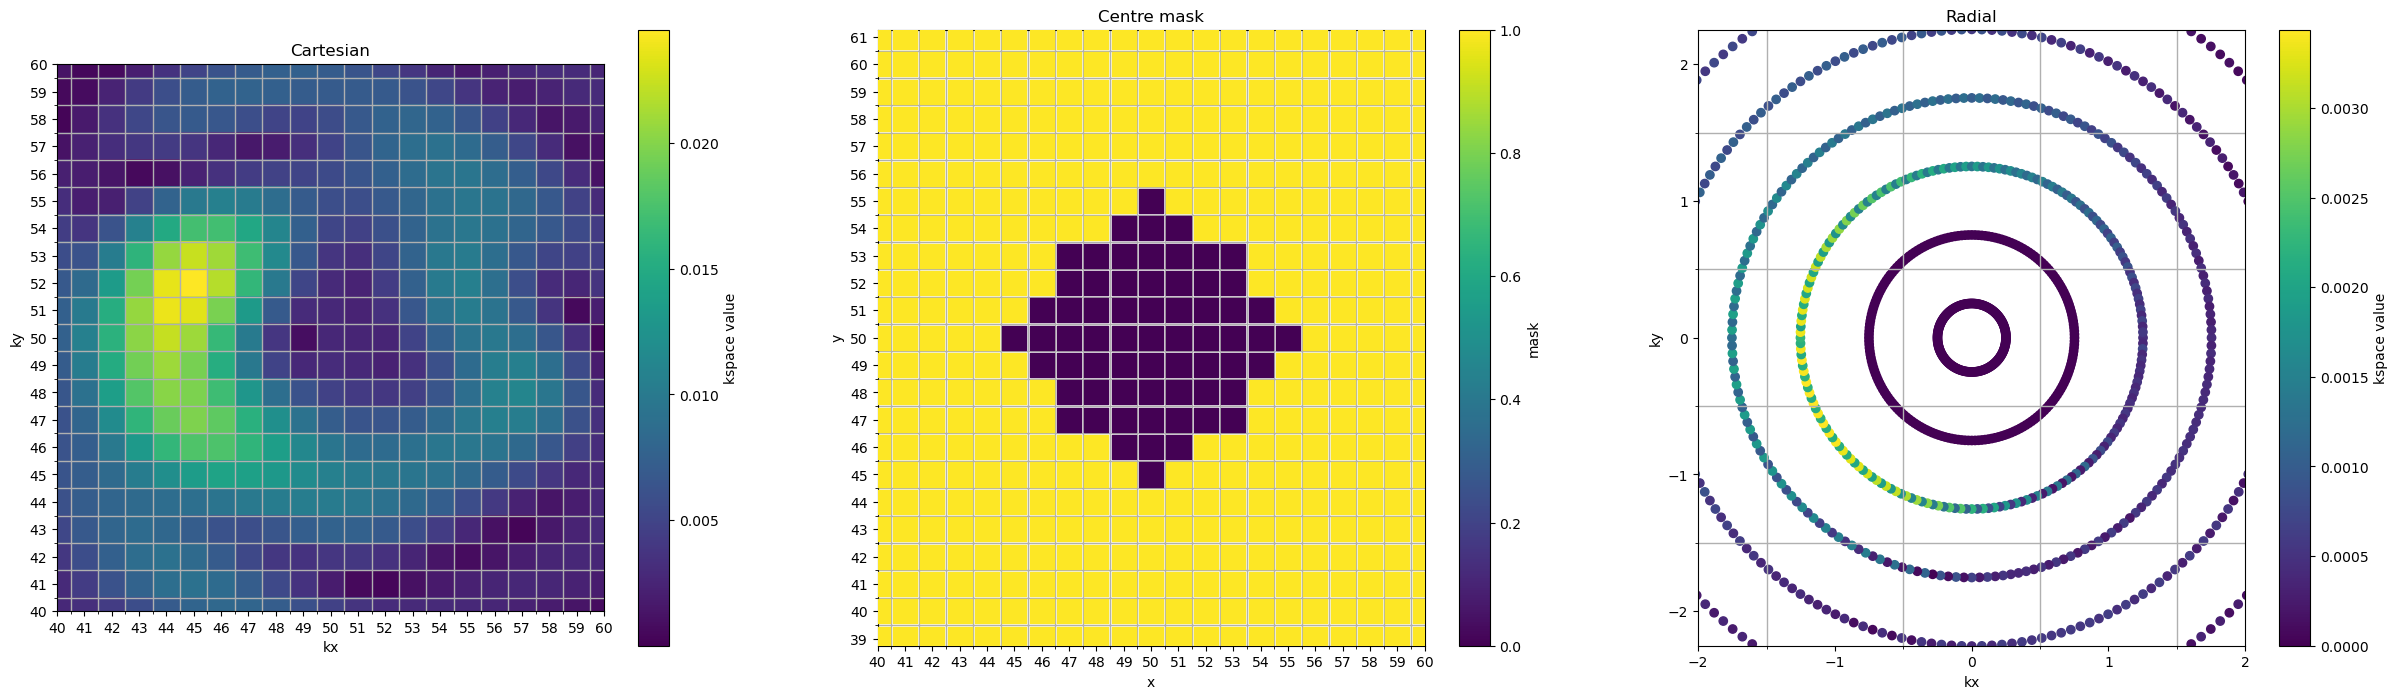

In [80]:
cy, cx = inner_wid // 2, inner_wid // 2
r = 4  # radius in pixels; adjust to cover the gap
yy, xx = np.ogrid[:inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

mask[(cx-5):(cx+6), cy] = False
mask[(cx), (cy-5):(cy+6)] = False


masked_inner = inner_region.copy()
masked_inner[:,~mask] = 0

inner_removed = inner_region.copy()
inner_removed[:,mask] = 0

totalwid = 1024
totaldiv = totalwid // 2

mask2 = np.ones((totalwid, totalwid), dtype=bool)

mask2[(indiv2-3):(indiv2+3), indiv2:indiv2+1] = False
mask2[(indiv2), (indiv2-2):(indiv2+3)] = False


plot_mask(inner_region, mask=mask, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)

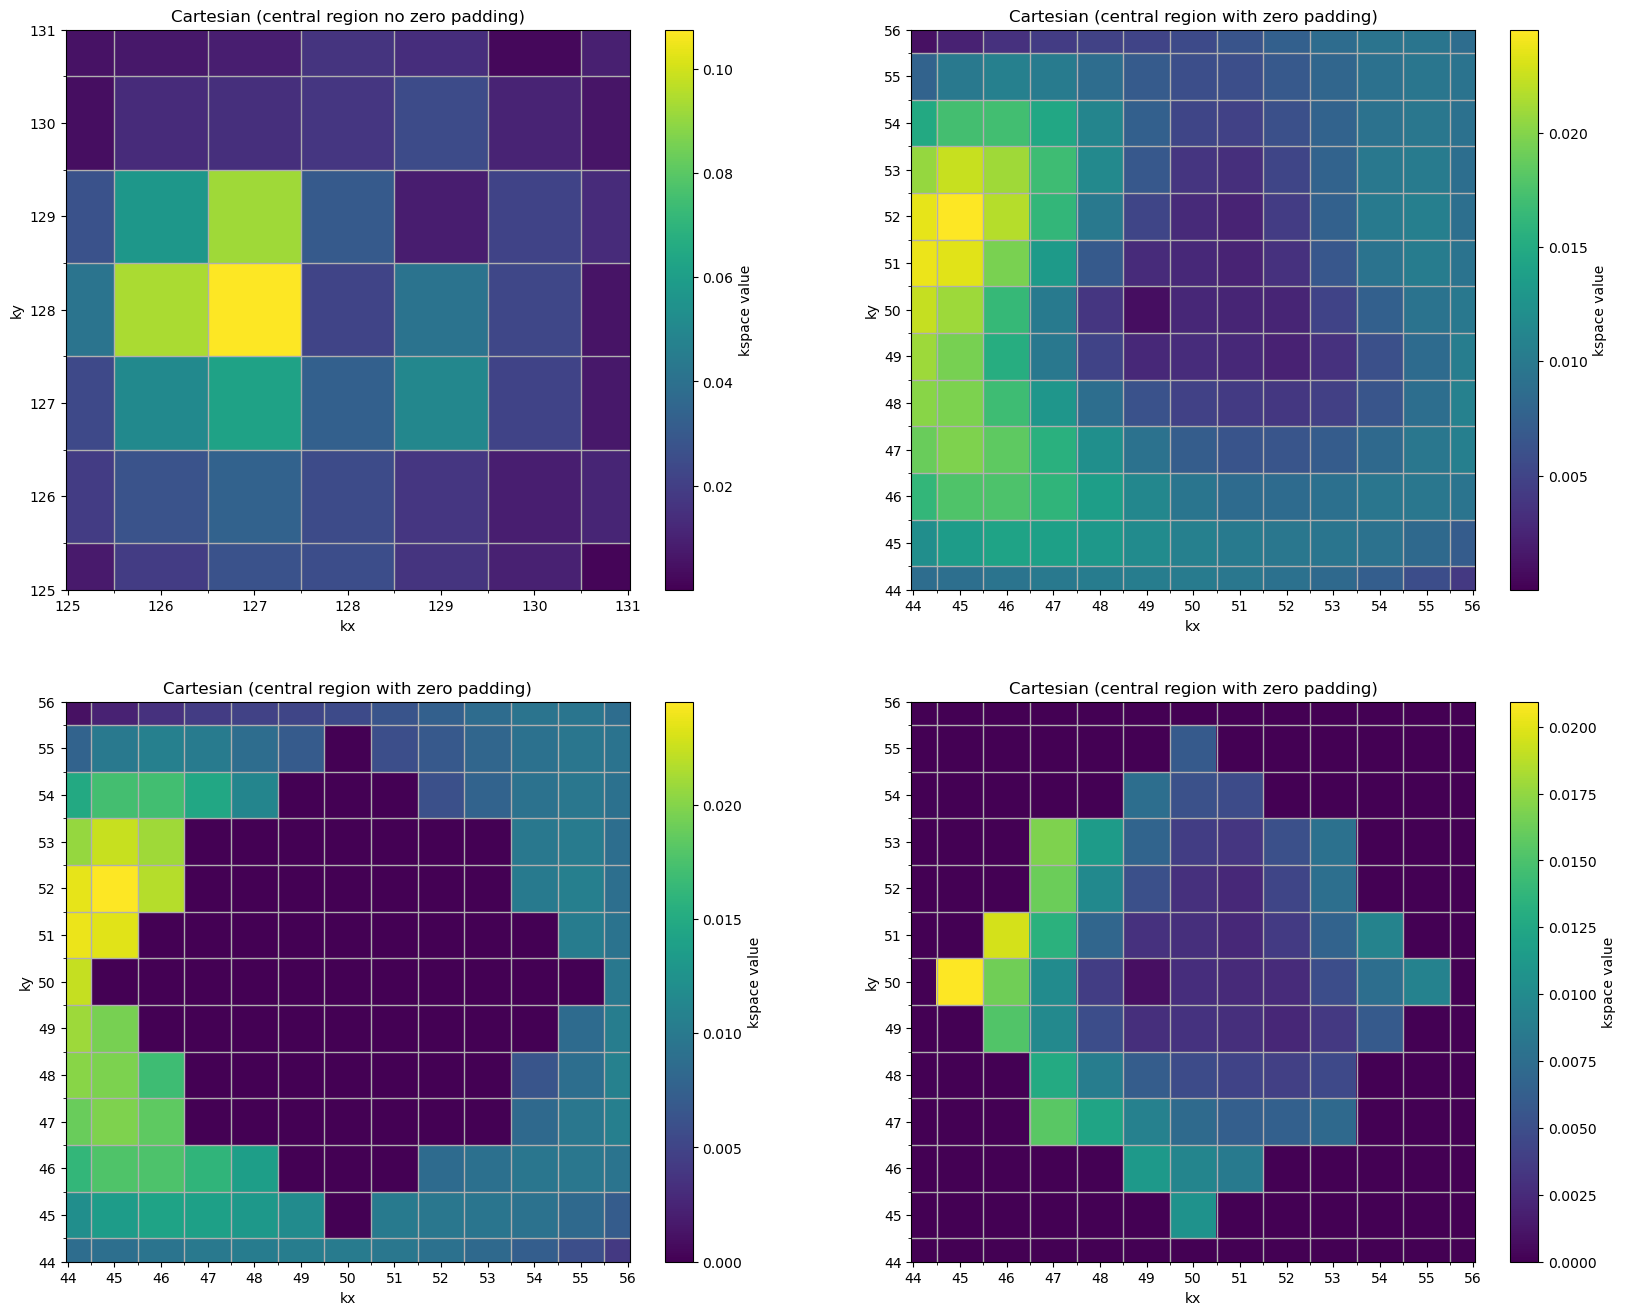

In [81]:
all_coords = zte_radial_coordsdlt.reshape(-1, 2)

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(20, 16))


im_new = ax[0, 0].imshow(np.abs(cartesian_zte[0]), cmap='viridis', origin='lower')
fig.colorbar(im_new, ax=ax[0, 0], label='kspace value')

ax[0, 0].set_title('Cartesian (central region no zero padding)')
ax[0, 0].set_xlabel('kx')
ax[0, 0].set_ylabel('ky')
ax[0, 0].axis('equal')
ax[0, 0].set_xlim(256/2 - 3,256/2 + 3)
ax[0, 0].set_ylim(256/2 - 3,256/2 + 3)
ax[0, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0, 0].grid(visible=True, which='minor', linewidth=1)
ax[0, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0, 0].yaxis.set_major_locator(plt.MultipleLocator(1))


im = ax[0, 1].imshow(np.abs(inner_region[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[0, 1], label='kspace value')

ax[0, 1].set_title('Cartesian (central region with zero padding)')
ax[0, 1].set_xlabel('kx')
ax[0, 1].set_ylabel('ky')
ax[0, 1].axis('equal')
ax[0, 1].set_xlim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[0, 1].set_ylim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[0, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[0, 1].grid(visible=True, which='minor', linewidth=1)
ax[0, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[0, 1].yaxis.set_major_locator(plt.MultipleLocator(1))


im = ax[1, 0].imshow(np.abs(masked_inner[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1, 0], label='kspace value')

ax[1, 0].set_title('Cartesian (central region with zero padding)')
ax[1, 0].set_xlabel('kx')
ax[1, 0].set_ylabel('ky')
ax[1, 0].axis('equal')
ax[1, 0].set_xlim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[1, 0].set_ylim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[1, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].grid(visible=True, which='minor', linewidth=1)
ax[1, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 0].yaxis.set_major_locator(plt.MultipleLocator(1))


im = ax[1, 1].imshow(np.abs(inner_removed[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1, 1], label='kspace value')

ax[1, 1].set_title('Cartesian (central region with zero padding)')
ax[1, 1].set_xlabel('kx')
ax[1, 1].set_ylabel('ky')
ax[1, 1].axis('equal')
ax[1, 1].set_xlim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[1, 1].set_ylim(inner_wid/2 - 6,inner_wid/2 + 6)
ax[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].grid(visible=True, which='minor', linewidth=1)
ax[1, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 1].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.show()

In [15]:
def LORAKS_loop(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask):
    ksp_forhankel = cartesian_inputkspace.copy()
    iter_count = 0
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
        U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh

        kspace_cart_coils_recon = asm.hankel_H_averaged(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        for coil in range(ksp_forhankel.shape[0]):
            kspace_cart_coils_consistent[coil, dtg_mask] = cartesian_inputkspace[coil, dtg_mask]
        ksp_forhankel = kspace_cart_coils_consistent.copy()
        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    return(output_kspace)

## Storing the inner kspace values to visualise convergence

1. At each iteration take the array and flatten
2. Take the square root of the sum of all the squared values and store
3. For each iteration, calculate the relative change by subtracting k from k-1 then dividing by k-1

Note:
1. Likely quicker to prebuild the df
2. Likely quicker to calculate

In [17]:
#post_loop_kspace = LORAKS_loop(n_iters=num_iters, window_size=5, zero_thresh=0.2, cartesian_inputkspace=inner_region, dtg_mask=mask)

In [82]:
num_iters=50

In [83]:
ksp_forhankel = inner_region.copy()

deltas = []
k_prev = None
window_size = 5

iter_count = 0
while iter_count < num_iters:
    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
    U, S_reduced, Vh = asm.sig_val_thresholding(data=hankel_matrix, zero_thresh=0.2)
    data_recon = (U * S_reduced) @ Vh

    kspace_cart_coils_recon = asm.hankel_H_averaged(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
    kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

    for coil in range(ksp_forhankel.shape[0]):
        kspace_cart_coils_consistent[coil, mask] = inner_region[coil, mask]
    ksp_forhankel = kspace_cart_coils_consistent.copy()

    vec = ksp_forhankel[:, ~mask]

    if k_prev is not None:
        deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
    k_prev = vec.copy()

    
    iter_count += 1

output_kspace = ksp_forhankel.copy()

In [ ]:
vec

Text(0, 0.5, 'relative change')

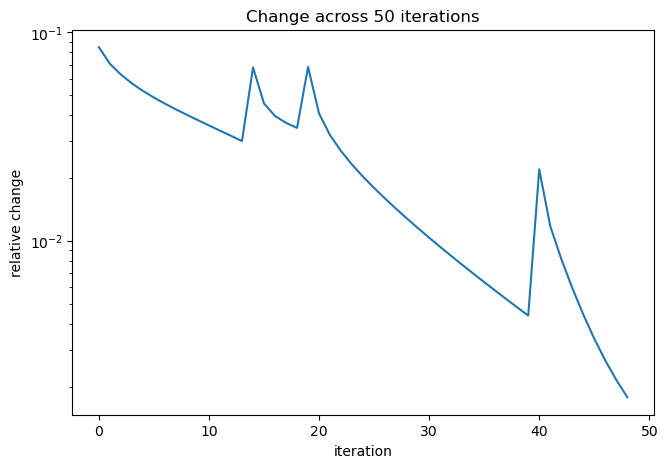

In [84]:
plt.figure(figsize=(7.5,5))
plt.semilogy(deltas)
plt.title(f'Change across {num_iters} iterations')
plt.xlabel("iteration")
plt.ylabel("relative change")

In [85]:
recombined = jigsaw(output_kspace=output_kspace, isolation_mask = inner_mask, start=start, end=end, enlarged_kspace=cartesian_kspace_enl)
cartesian_kspace_rebuild = asm.zero_padding(recombined, 256,256)
post_loop_kspace = output_kspace.copy()

In [86]:
zte_radial_kspace1, zte_radial_coords1 = asm.generate_zte_data_OLD(ksp=ksp, coord=coord, n_missing=1, undersampling_factor=1)
dcf1 = (zte_radial_coords1[...,0]**2 + zte_radial_coords1[...,1]**2)**0.5
im_grid = sp.nufft_adjoint(zte_radial_kspace1* dcf1, zte_radial_coords1)

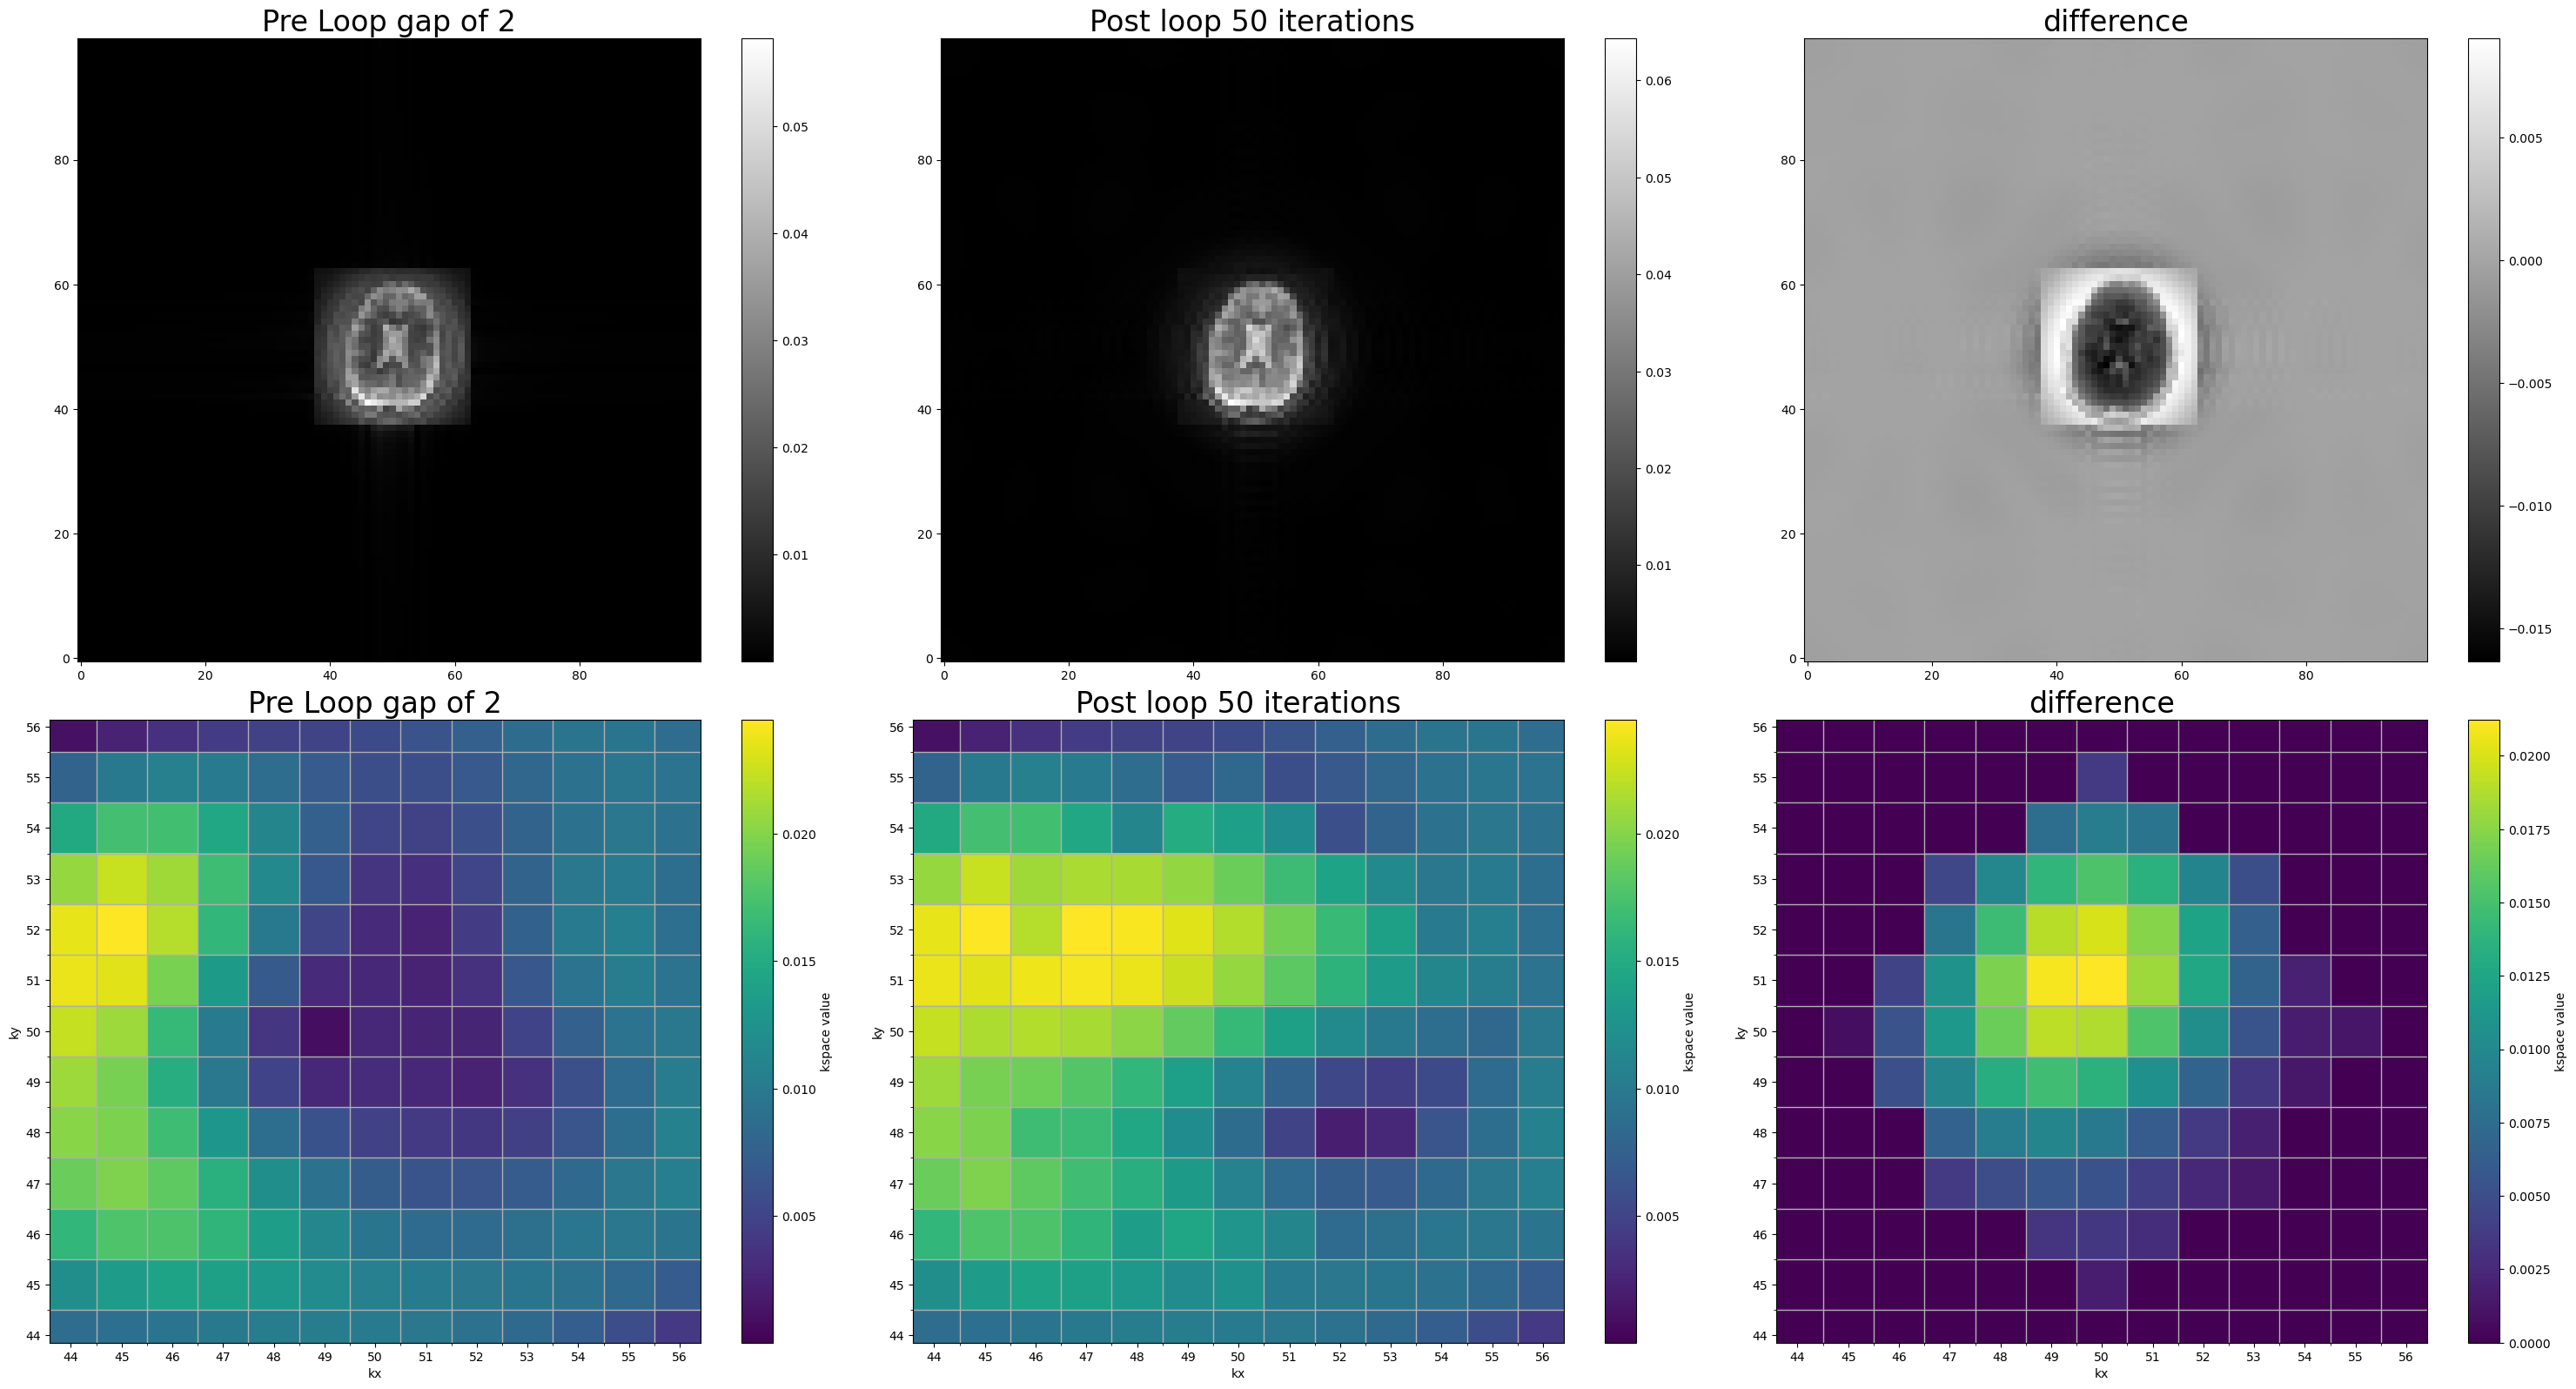

In [87]:
fig, ax = plt.subplots(nrows=2, ncols=3, figsize=(30, 16))

# Row 0: image-space magnitude
im1 = np.sum(np.abs(sp.ifft(inner_region))**2, axis=0)**0.5
p0 = ax[0, 0].imshow(im1, cmap='gray', origin='lower')
ax[0, 0].set_title(f'Pre Loop gap of {gap}', fontsize=24)
fig.colorbar(p0, ax=ax[0, 0])

im2 = np.sum(np.abs(sp.ifft(post_loop_kspace))**2, axis=0)**0.5
p1 = ax[0, 1].imshow(im2, cmap='gray', origin='lower')
ax[0, 1].set_title(f'Post loop {50} iterations', fontsize=24)
fig.colorbar(p1, ax=ax[0, 1])

p2 = ax[0, 2].imshow(im1-im2, cmap='gray', origin='lower')
ax[0, 2].set_title('difference', fontsize=24)
fig.colorbar(p2, ax=ax[0, 2])

# Row 1: k-space
all_coords = zte_radial_coordsdlt.reshape(-1, 2)

im = ax[1, 0].imshow(np.abs(inner_region[0]), cmap='viridis', origin='lower')
fig.colorbar(im, ax=ax[1, 0], label='kspace value')
ax[1, 0].set_title(f'Pre Loop gap of {gap}', fontsize=24)
ax[1, 0].set_xlabel('kx')
ax[1, 0].set_ylabel('ky')
ax[1, 0].axis('equal')
ax[1, 0].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 0].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 0].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 0].grid(visible=True, which='minor', linewidth=1)
ax[1, 0].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 0].yaxis.set_major_locator(plt.MultipleLocator(1))

im1k = ax[1, 1].imshow(np.abs(post_loop_kspace[0]), cmap='viridis', origin='lower')
fig.colorbar(im1k, ax=ax[1, 1], label='kspace value')
ax[1, 1].set_title(f'Post loop {50} iterations', fontsize=24)
ax[1, 1].set_xlabel('kx')
ax[1, 1].set_ylabel('ky')
ax[1, 1].axis('equal')
ax[1, 1].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 1].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 1].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 1].grid(visible=True, which='minor', linewidth=1)
ax[1, 1].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 1].yaxis.set_major_locator(plt.MultipleLocator(1))

diff = inner_region - post_loop_kspace

im2k = ax[1, 2].imshow(np.abs(diff[0]), cmap='viridis', origin='lower')
fig.colorbar(im2k, ax=ax[1, 2], label='kspace value')
ax[1, 2].set_title('difference', fontsize=24)
ax[1, 2].set_xlabel('kx')
ax[1, 2].set_ylabel('ky')
ax[1, 2].axis('equal')
ax[1, 2].set_xlim(100/2 - 6, 100/2 + 6)
ax[1, 2].set_ylim(100/2 - 6, 100/2 + 6)
ax[1, 2].xaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].yaxis.set_minor_locator(plt.MultipleLocator(1, offset=0.5))
ax[1, 2].grid(visible=True, which='minor', linewidth=1)
ax[1, 2].xaxis.set_major_locator(plt.MultipleLocator(1))
ax[1, 2].yaxis.set_major_locator(plt.MultipleLocator(1))

plt.tight_layout()
plt.show()

In [4]:
print(np.__version__, sp.__version__)

1.26.4 0.1.27


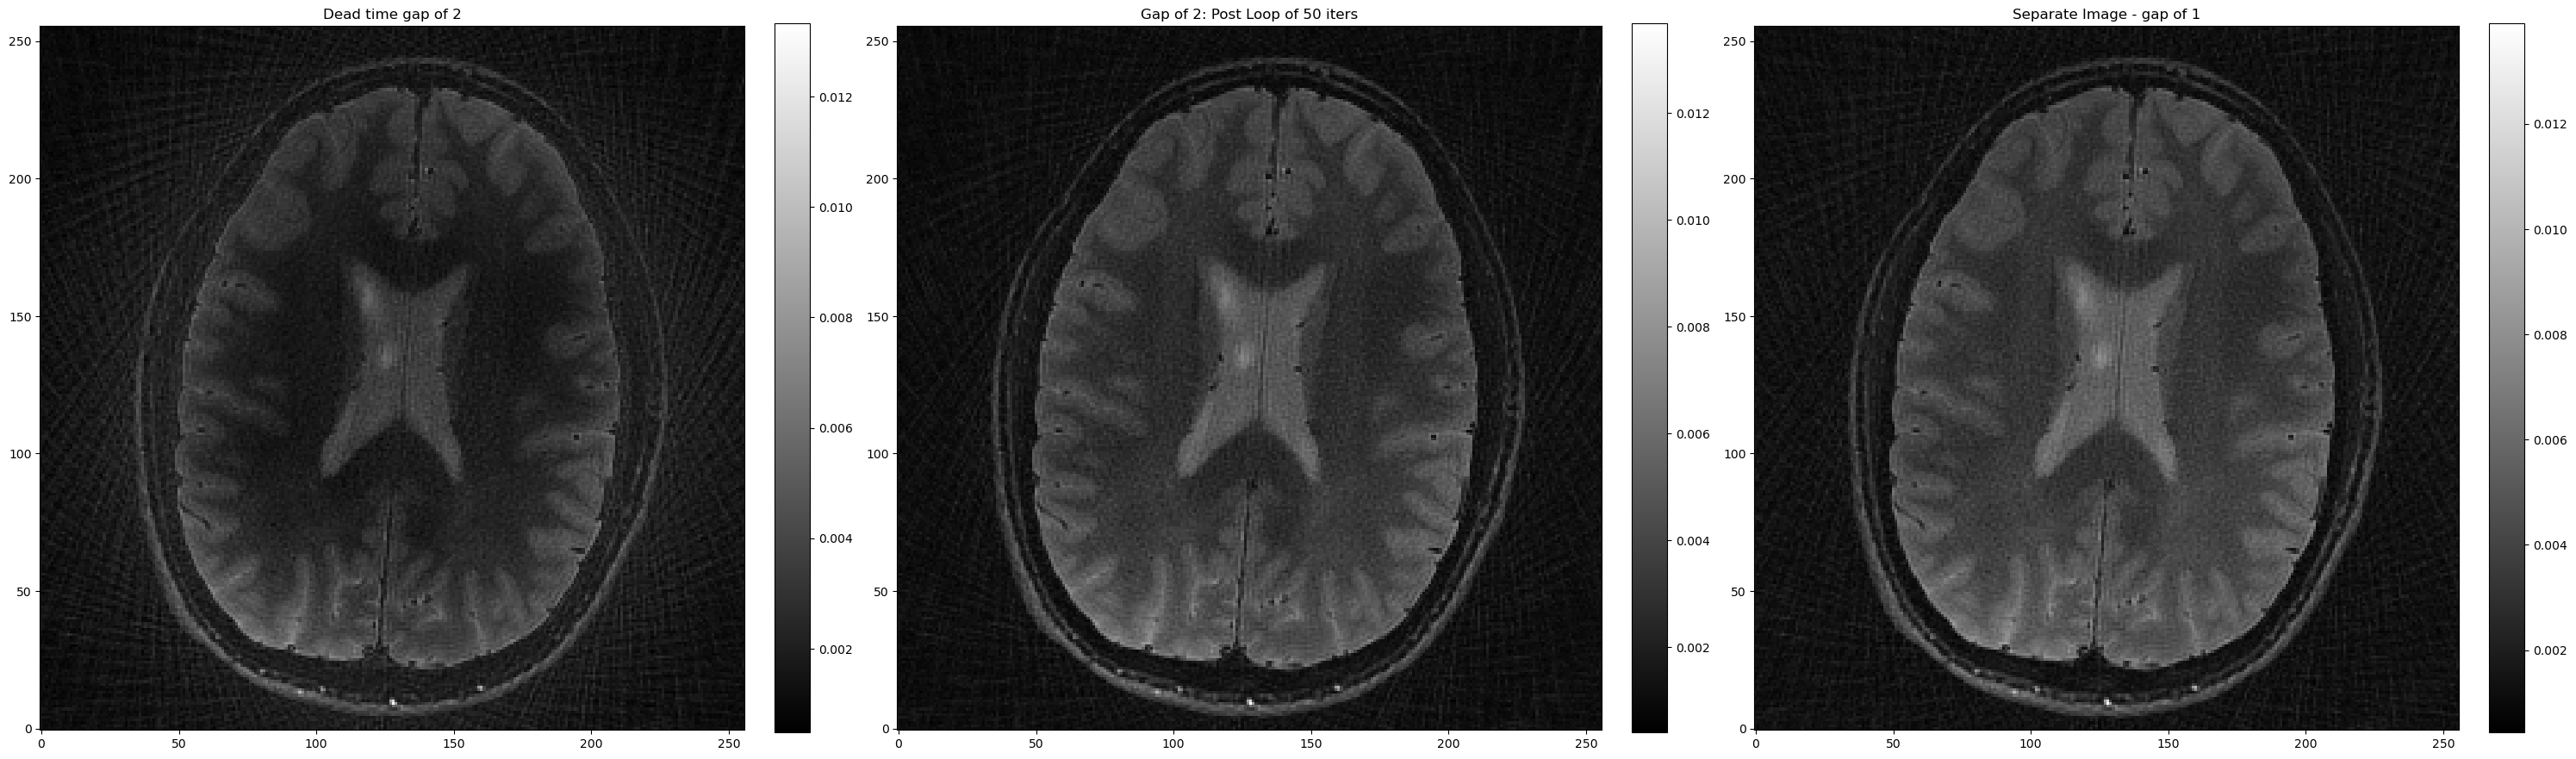

In [88]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 16))


im_grid1 = sp.ifft(cartesian_zte, axes=(-2, -1))
im_1 = np.sum(np.abs(im_grid1)**2, axis=0)**0.5
p0 = ax[0].imshow(im_1, cmap='gray', origin='lower')
ax[0].set_title(f'Dead time gap of {gap}')
fig.colorbar(p0, ax=ax[0], fraction=0.046, pad=0.04)

im_grid2 = sp.ifft(cartesian_kspace_rebuild, axes=(-2, -1))
im_2 = np.sum(np.abs(im_grid2)**2, axis=0)**0.5
p1 = ax[1].imshow(im_2, cmap='gray', origin='lower')
ax[1].set_title(f'Gap of 2: Post Loop of {num_iters} iters')
fig.colorbar(p1, ax=ax[1], fraction=0.046, pad=0.04)

img_3 = np.sum(np.abs(im_grid)**2, axis=0)**0.5
p2 = ax[2].imshow(img_3, cmap='gray', origin='lower')
ax[2].set_title('Separate Image - gap of 1')
fig.colorbar(p2, ax=ax[2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()